In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d jangedoo/utkface-new
!unzip -q utkface-new.zip

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
 87% 288M/331M [00:00<00:00, 868MB/s] 
100% 331M/331M [00:00<00:00, 806MB/s]


In [3]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [4]:
data_path = "UTKFace"

filepaths = []
ages = []
genders = []

for file in os.listdir(data_path):
    try:
        age = int(file.split("_")[0])
        gender = int(file.split("_")[1])

        filepaths.append(os.path.join(data_path, file))
        ages.append(age)
        genders.append(gender)
    except:
        continue

df = pd.DataFrame({
    "filename": filepaths,
    "age": ages,
    "gender": genders
})

# 🔥 IMPORTANT FIX
df["age"] = df["age"].astype("float32")
df["gender"] = df["gender"].astype("float32")

df.head()

,filename,age,gender
0,UTKFace/28_1_2_20170116190118355.jpg.chip.jpg,28.0,1.0
1,UTKFace/25_0_0_20170120134516424.jpg.chip.jpg,25.0,0.0
2,UTKFace/28_1_3_20170104231853785.jpg.chip.jpg,28.0,1.0
3,UTKFace/51_0_0_20170111181750489.jpg.chip.jpg,51.0,0.0
4,UTKFace/19_0_2_20170104020121132.jpg.chip.jpg,19.0,0.0


In [5]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [6]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.0
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col=["gender", "age"],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw"
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col=["gender", "age"],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw"
)

Found 18966 validated image filenames.
Found 4742 validated image filenames.


In [8]:
def multi_output_generator(generator):
    while True:
        X, y = next(generator)
        yield X, (y[:, 0], y[:, 1])

train_gen = multi_output_generator(train_generator)
val_gen = multi_output_generator(val_generator)

In [9]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers[:-4]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)

# 🔥 IMPORTANT: NAME THE OUTPUTS
gender_output = Dense(1, activation="sigmoid", name="gender")(x)
age_output = Dense(1, activation="linear", name="age")(x)

model = Model(inputs=base_model.input, outputs=[gender_output, age_output])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss={
        "gender": "binary_crossentropy",
        "age": "mae"
    },
    metrics={
        "gender": "accuracy",
        "age": "mae"
    }
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 8, 8, 512) │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 8, 8, 512) │  2,359,808 │ block5_conv1[0][

 Total params: 14,978,370 (57.14 MB)

 Trainable params: 7,343,106 (28.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_gender_accuracy",  # monitor gender accuracy
    patience=3,                     # stop after 3 bad epochs
    mode="max",
    restore_best_weights=True,
    verbose=1
)

In [11]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 145s 225ms/step - age_loss: 12.9371 - age_mae: 12.9371 - gender_accuracy: 0.6402 - gender_loss: 0.9549 - loss: 13.8920 - val_age_loss: 7.6147 - val_age_mae: 7.6048 - val_gender_accuracy: 0.8484 - val_gender_loss: 0.3701 - val_loss: 7.9767
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 121s 205ms/step - age_loss: 8.2864 - age_mae: 8.2864 - gender_accuracy: 0.8028 - gender_loss: 0.4946 - loss: 8.7810 - val_age_loss: 7.4167 - val_age_mae: 7.4167 - val_gender_accuracy: 0.8742 - val_gender_loss: 0.2839 - val_loss: 7.7006
Epoch 3/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 120s 202ms/step - age_loss: 7.5129 - age_mae: 7.5129 - gender_accuracy: 0.8281 - gender_loss: 0.4206 - loss: 7.9335 - val_age_loss: 6.8455 - val_age_mae: 6.8455 - val_gender_accuracy: 0.8947 - val_gender_loss: 0.2478 - val_loss: 7.0933
Epoch 4/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 119s 201ms/step - age_loss: 7.1595 - age_mae: 7.1595 - gender_accuracy: 0.8429 - gender_loss: 0.3736 - loss: 7.5331 - val_age_los

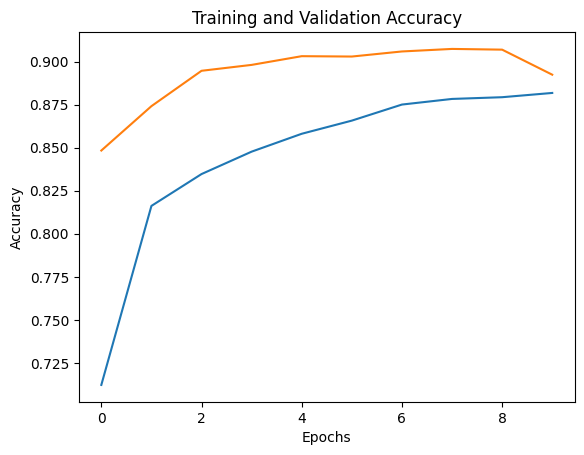

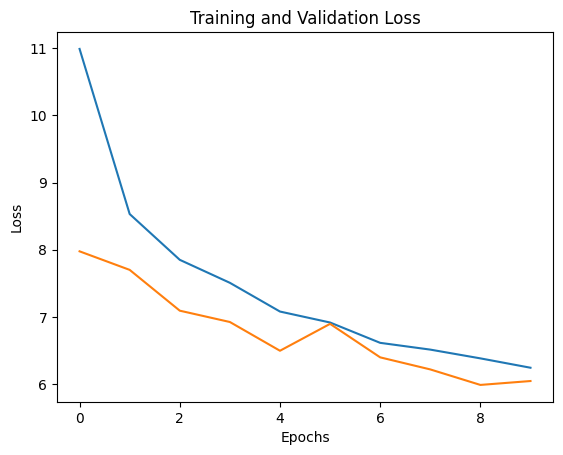

In [12]:
import matplotlib.pyplot as plt

history = model.history.history   # agar aapne model.fit() run kiya hai

# Accuracy Graph
plt.figure()
plt.plot(history['gender_accuracy'])
plt.plot(history['val_gender_accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.show()

# Loss Graph
plt.figure()
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

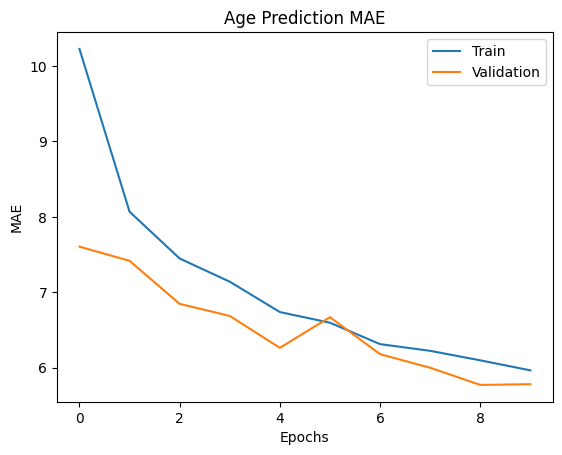

In [23]:
plt.figure()
plt.plot(history['age_mae'])
plt.plot(history['val_age_mae'])
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("Age Prediction MAE")
plt.legend(["Train", "Validation"])
plt.show()

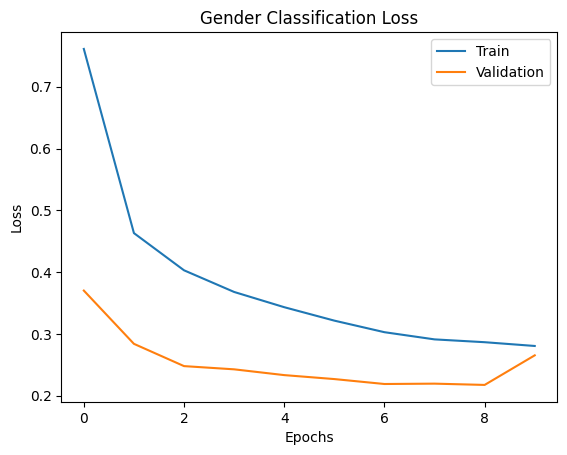

In [24]:
plt.figure()
plt.plot(history['gender_loss'])
plt.plot(history['val_gender_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Gender Classification Loss")
plt.legend(["Train", "Validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Gender: Male
Predicted Age: 30


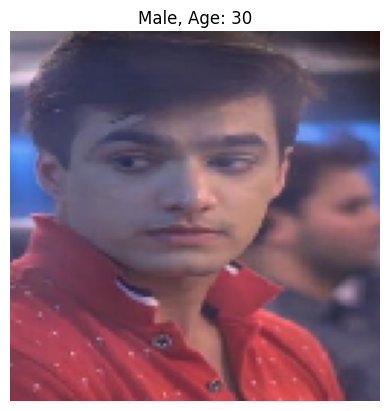

In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Test image path
img_path = "/content/men.jpg"   # ← apni image ka path likho

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0   # agar training me normalization kiya tha

# Predict (2 outputs)
pred_gender, pred_age = model.predict(img_array)

gender = "Male" if pred_gender[0][0] < 0.5 else "Female"
age = int(pred_age[0][0])

print("Gender:", gender)
print("Predicted Age:", age)

plt.imshow(img)
plt.title(f"{gender}, Age: {age}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Gender: Female
Predicted Age: 31


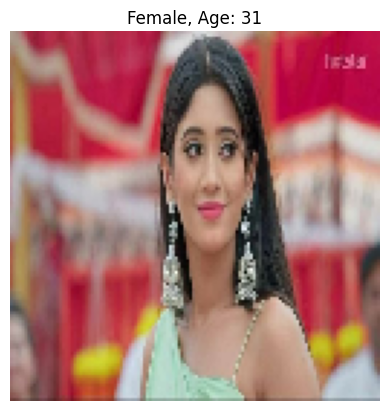

In [18]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Test image path
img_path = "/content/women.jpg"   # ← apni image ka path likho

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0   # agar training me normalization kiya tha

# Predict (2 outputs)
pred_gender, pred_age = model.predict(img_array)

gender = "Male" if pred_gender[0][0] < 0.5 else "Female"
age = int(pred_age[0][0])

print("Gender:", gender)
print("Predicted Age:", age)

plt.imshow(img)
plt.title(f"{gender}, Age: {age}")
plt.axis("off")
plt.show()

In [19]:
print(pred_age)

[[31.225542]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Gender: Female
Predicted Age: 39


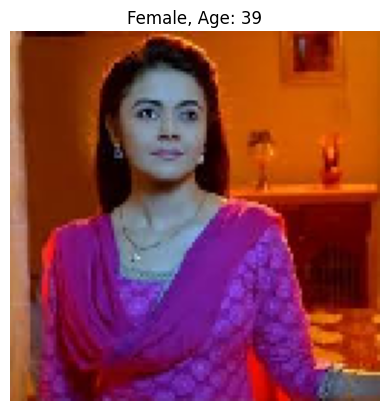

In [21]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Test image path
img_path = "/content/women1.jpg"   # ← apni image ka path likho

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0   # agar training me normalization kiya tha

# Predict (2 outputs)
pred_gender, pred_age = model.predict(img_array)

gender = "Male" if pred_gender[0][0] < 0.5 else "Female"
age = int(pred_age[0][0])

print("Gender:", gender)
print("Predicted Age:", age)

plt.imshow(img)
plt.title(f"{gender}, Age: {age}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Gender: Female
Predicted Age: 44


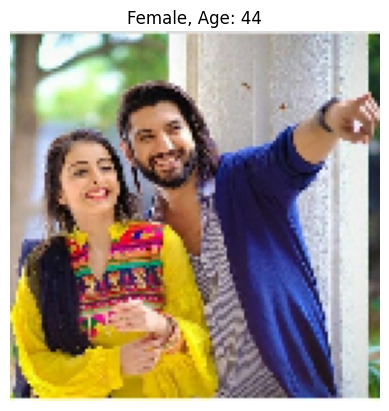

In [25]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Test image path
img_path = "/content/both.jpg"   # ← apni image ka path likho

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0   # agar training me normalization kiya tha

# Predict (2 outputs)
pred_gender, pred_age = model.predict(img_array)

gender = "Male" if pred_gender[0][0] < 0.5 else "Female"
age = int(pred_age[0][0])

print("Gender:", gender)
print("Predicted Age:", age)

plt.imshow(img)
plt.title(f"{gender}, Age: {age}")
plt.axis("off")
plt.show()